# XRD-CT (diffraction tomography) with MIDAS — a walkthrough

**Audience:** you have run a diffraction-tomography scan (sample translated
across the beam and rotated, one detector frame per translation+rotation) and
want per-voxel diffraction patterns and maps out of it. **No prior MIDAS
experience assumed.**

This notebook runs end to end on synthetic data it generates itself, so you can
step through it now and see what every stage should look like. Then change one
flag in §1 and it runs on your own scan.

### What XRD-CT gives you

A normal powder measurement gives one pattern for the whole illuminated volume.
XRD-CT resolves it: after reconstruction **every voxel has its own diffraction
pattern**, so you can map phase distribution, lattice parameter (hence strain),
peak width (hence microstructure) across a slice.

### What you need before starting

| | | |
|---|---|---|
| the scan | one file per translation, frames stacked inside | §1 `RAW_DIR`, `STEM` |
| a dark | detector reading with no beam | §1 `DARK_FILE` |
| calibration | distance, beam centre, pixel size, wavelength | §1 `GEOMETRY` |
| the rotation | start angle and step | §1 `START_OMEGA`, `OMEGA_STEP` |
| two conventions | ω sign, and whether frame 1 is a throwaway | §1 — **read that part** |

If you do not have calibration yet, run a calibrant (CeO2, LaB6, Si) and use
`midas-calibrate-v2`; XRD-CT cannot be done without it, because every radius
you fit converts to a d-spacing through the geometry.

### Is XRD-CT even the right technique for your sample?

Only if the rings are **continuous**. If they break into discrete spots, your
grains are large compared to the beam and you want scanning-3DXRD instead
(`midas_index` PF mode + `midas_pf_odf`), which treats each spot individually.
§4 makes that check on your data rather than assuming.

### Runtime

The synthetic demo takes about a minute end to end. A real scan scales with
translations × rotations; §6 prints an estimate before committing.

## 0 · Setup

This reports what is installed. Nothing here is fatal — the notebook tells you
what any missing piece would have enabled.

In [1]:
%matplotlib inline
import sys, os, time, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Only needed when running from a source checkout rather than `pip install`.
_here = Path.cwd()
for cand in (_here.parent, _here.parent.parent / "midas_tomo", _here.parent.parent / "midas_invert"):
    if cand.is_dir() and str(cand) not in sys.path:
        sys.path.insert(0, str(cand))
sys.path.insert(0, str(_here))          # for _demo.py

import midas_dt
print(f"midas-dt {midas_dt.__version__}")

# The gridrec reconstruction engine is C, compiled at install time. Without it
# nothing can be reconstructed, so check first rather than failing in §8.
from midas_tomo import backend_c
if backend_c.available():
    print(f"reconstruction engine: OK  ({backend_c.binary_path().name})")
else:
    print("reconstruction engine: MISSING\n  " + backend_c.why_unavailable())

def _has(mod, what):
    try:
        __import__(mod); print(f"{mod}: OK  ({what})"); return True
    except ImportError:
        print(f"{mod}: not installed  -- {what} unavailable"); return False

HAVE_SCIPY = _has("scipy", "peak fitting and ring finding")
HAVE_TORCH = _has("torch", "branch C (direct inversion), SIRT/TV, absorption")

midas-dt 0.3.0
reconstruction engine: OK  (MIDAS_TOMO)
scipy: OK  (peak fitting and ring finding)


torch: OK  (branch C (direct inversion), SIRT/TV, absorption)


## 1 · Configure — this is the only cell you need to edit

Everything below §1 runs unchanged.

### The two conventions that will silently ruin a reconstruction

`midas-dt` was written at APS 1-ID, and two of its defaults come from that
beamline's habits. **They are almost certainly wrong for a different
instrument, and both fail quietly** — you get a clean-looking reconstruction of
the wrong thing, with no error.

**`NEGATE_OMEGA`** — 1-ID's aerotech rotation stage reports angles with the
opposite sign to the convention the reconstruction assumes. Getting this wrong
reconstructs a **mirror image** of your sample. It will look completely
reasonable. Check which way your stage turns, viewed along the beam.

**`DROP_FIRST_FRAME`** — 1-ID writes a throwaway frame at the start of every
acquisition. If your detector does not, dropping it shifts every projection to
the wrong angle by one step. If it does and you keep it, you fold a junk frame
into the sinogram.

To find out: count the frames in one file (§2 prints this). If it is one more
than the number of rotations you asked for, there is a throwaway.

Neither can be determined from the data alone with confidence, which is why
they are questions and not guesses. **Ask your beamline scientist.**

In [2]:
# ============================ EDIT FROM HERE ============================

USE_DEMO_DATA = True      # True: generate a synthetic scan and run on it.
                          # False: use YOUR data from the paths below.

OUT_DIR = Path("./dt_output")     # maps, figures and provenance land here

# ---- 1a. Where the scan is ------------------------------------------------
# Files are expected as <RAW_DIR>/<STEM>_<nnnnnn><EXT>, one per translation.
RAW_DIR   = Path("/path/to/your/raw/data")
STEM      = "my_dt_scan"
START_NR  = 1             # first file number
END_NR    = 55            # last file number  (=> 55 translations)
FILE_PAD  = 6             # digits in the number: 000001 -> 6
FILE_EXT  = ".raw"
DARK_FILE = RAW_DIR / "dark_before_000000.raw"

# ---- 1b. Detector file layout --------------------------------------------
# A raw file is: a fixed header, then frames back to back, no per-frame header.
DET_PIXELS_Y   = 1475          # horizontal
DET_PIXELS_Z   = 1679          # vertical
DET_DTYPE      = "<i4"         # little-endian int32; "<u2" for uint16, etc.
HEADER_BYTES   = 8192          # bytes before the first frame
FLIP_VERTICAL  = True          # Pilatus at 1-ID needs this (legacy ImTransOpt 2)

# ---- 1c. Calibration -----------------------------------------------------
LSD_UM        = 1_071_098.0    # sample-to-detector distance, micrometres
BEAM_CENTRE_Y = 790.31         # pixels, horizontal
BEAM_CENTRE_Z = 864.54         # pixels, vertical
PIXEL_UM      = 172.0          # pixel size, micrometres (square)
WAVELENGTH_A  = 0.136994       # Angstroms  (90.5 keV; E[keV] = 12.3984 / lambda)

# ---- 1d. The rotation ----------------------------------------------------
START_OMEGA = 180.25           # nominal angle of the first USED frame, degrees
OMEGA_STEP  = -0.25            # degrees per frame

# ---- 1e. Beamline conventions -- see the text above ----------------------
NEGATE_OMEGA     = True        # True at APS 1-ID. Wrong => mirrored sample.
DROP_FIRST_FRAME = True        # True at APS 1-ID. Wrong => angles off by one.

# ---- 1f. Which part of the pattern to reconstruct ------------------------
# Leave as None to let §5 find the rings and suggest a window.
CHANNEL_R_MIN = None           # e.g. 105.0  (detector radius, pixels)
CHANNEL_R_MAX = None           # e.g. 125.0
CHANNEL_R_BIN = 1.0            # radial bin size in pixels. Smaller = more
                               # reconstructions = slower. Start at 1.0.

N_CPUS = 4                     # threads for the reconstruction engine

# ============================= EDIT TO HERE =============================

## 2 · Open the scan and check it makes sense

Builds the demo data if you asked for it, then opens the scan **exactly the way
your own data will be opened** and prints what it found. Read the frame count
line against what you asked the detector for — that is how you settle
`DROP_FIRST_FRAME`.

In [3]:
from midas_dt import Channel, DTGeometry, DTScan, RawFormat, frames_in_file

if USE_DEMO_DATA:
    from _demo import make_scan
    demo = make_scan(OUT_DIR / "demo_data")
    print(f"synthetic scan: {demo.describe()}\n")
    # Point the configuration at what was just written.
    RAW_DIR, STEM = demo.directory, demo.stem
    START_NR, END_NR = demo.start_nr, demo.end_nr
    DARK_FILE = demo.dark_file
    DET_PIXELS_Y = DET_PIXELS_Z = demo.n_pixels
    BEAM_CENTRE_Y, BEAM_CENTRE_Z = demo.beam_centre
    DET_DTYPE, HEADER_BYTES, FLIP_VERTICAL = "<i4", 8192, False
    LSD_UM, PIXEL_UM, WAVELENGTH_A = 1_000_000.0, 200.0, 0.1377
    START_OMEGA, OMEGA_STEP = demo.start_omega, demo.omega_step
    NEGATE_OMEGA, DROP_FIRST_FRAME = False, True
else:
    demo = None
    if not RAW_DIR.is_dir():
        raise FileNotFoundError(
            f"RAW_DIR does not exist: {RAW_DIR}\n"
            f"Set USE_DEMO_DATA = True to try the notebook on synthetic data.")

fmt = RawFormat(n_pixels_y=DET_PIXELS_Y, n_pixels_z=DET_PIXELS_Z,
                dtype=np.dtype(DET_DTYPE), header_bytes=HEADER_BYTES,
                flip_vertical=FLIP_VERTICAL)

# RhoD normalises the radial-distortion terms. With no distortion fitted it
# only has to be self-consistent; beam-centre-to-farthest-corner is the
# convention, and a wrong value silently rescales any distortion correction.
RHO_D_UM = float(np.hypot(max(BEAM_CENTRE_Y, DET_PIXELS_Y - BEAM_CENTRE_Y),
                          max(BEAM_CENTRE_Z, DET_PIXELS_Z - BEAM_CENTRE_Z)) * PIXEL_UM)

geo = DTGeometry(lsd_um=LSD_UM, bc_y_px=BEAM_CENTRE_Y, bc_z_px=BEAM_CENTRE_Z,
                 px_um=PIXEL_UM, n_pixels_y=DET_PIXELS_Y, n_pixels_z=DET_PIXELS_Z,
                 wavelength_a=WAVELENGTH_A, rho_d_um=RHO_D_UM)

first = RAW_DIR / f"{STEM}_{START_NR:0{FILE_PAD}d}{FILE_EXT}"
if not first.is_file():
    raise FileNotFoundError(f"first file not found: {first}")
n_in_file = frames_in_file(first, fmt)

scan = DTScan.from_stem(RAW_DIR, STEM, START_NR, END_NR, pad=FILE_PAD,
                        ext=FILE_EXT, fmt=fmt, start_omega=START_OMEGA,
                        omega_step=OMEGA_STEP, negate_omega=NEGATE_OMEGA,
                        dark_file=DARK_FILE, drop_first_frame=DROP_FIRST_FRAME)

print(f"geometry : {geo.describe()}")
print(f"           beam energy {geo.energy_kev:.2f} keV")
print(f"scan     : {scan.describe()}")
print()
print(f"frames per file on disk : {n_in_file}")
print(f"frames the notebook will use : {scan.n_frames}"
      f"   (DROP_FIRST_FRAME={DROP_FIRST_FRAME})")
print(f"  -> if {n_in_file} is one MORE than the number of rotations you")
print(f"     requested, DROP_FIRST_FRAME=True is correct.")
print()
print(f"omega    : {scan.omega_deg[0]:.2f} to {scan.omega_deg[-1]:.2f} deg"
      f"   (NEGATE_OMEGA={NEGATE_OMEGA})")
span = abs(scan.omega_deg[-1] - scan.omega_deg[0])
if span < 170:
    print(f"  WARNING: only {span:.0f} deg of rotation. Tomography needs ~180.")

synthetic scan: 16 translations x 24 rotations of 192x192 px, rings at 55 and 80 px

geometry : Lsd 1000000.0 um, BC (95.500, 95.500) px, px 200 um, 192x192, lambda 0.137700 A = 90.04 keV, tilts (0, 0, 0) deg
           beam energy 90.04 keV
scan     : 16 translations x 24 frames (192x192, int32), 0.00 GB/translation, omega 7.50..180.00 deg, snake=False, drop_first_frame=True

frames per file on disk : 25
frames the notebook will use : 24   (DROP_FIRST_FRAME=True)
  -> if 25 is one MORE than the number of rotations you
     requested, DROP_FIRST_FRAME=True is correct.

omega    : 7.50 to 180.00 deg   (NEGATE_OMEGA=False)


## 3 · Look at a raw frame before trusting anything derived from it

Everything after this point is mediated by integration and fitting. This is the
one place you see the actual measurement, and it answers two questions at once:

1. **Is the geometry right?** The red cross is your beam centre and the circles
   are drawn at radii found from the data. If the circles do not sit on the
   rings, `BEAM_CENTRE_*`, `PIXEL_UM` or `LSD_UM` is wrong, and every d-spacing
   downstream will be wrong with it.
2. **Are the rings continuous?** See §4.

Frames are summed to beat down noise — a single short exposure of a weak ring
can look spotty purely from counting statistics.

translation 8, 20 frames averaged, dark subtracted
  min 8.9  median 13.2  max 852.9


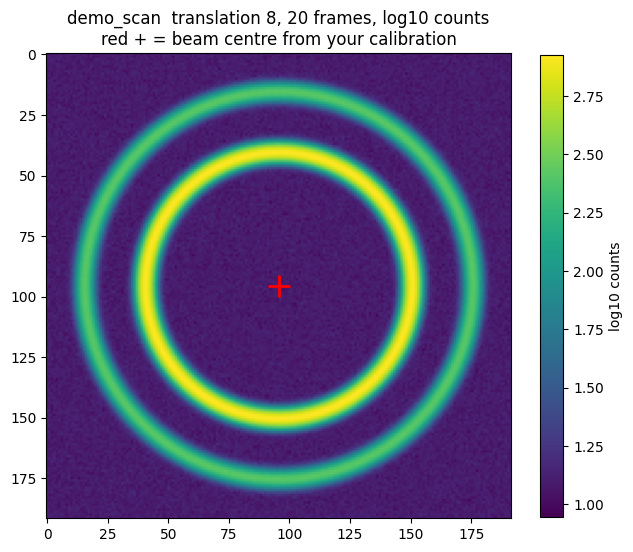

In [4]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG = OUT_DIR / "figures"; FIG.mkdir(exist_ok=True)

mid_t = scan.n_translations // 2
n_sum = min(20, scan.n_frames)
idx = np.linspace(0, scan.n_frames - 1, n_sum).astype(int)

dark = scan.dark()
acc = np.zeros(fmt.frame_shape, dtype=np.float64)
for f in idx:
    acc += scan.frame(mid_t, int(f)).astype(np.float64)
frame = acc / len(idx) - dark

print(f"translation {mid_t}, {len(idx)} frames averaged, dark subtracted")
print(f"  min {frame.min():.1f}  median {np.median(frame):.1f}  max {frame.max():.1f}")

# NOTE: scan.frame() has already applied FLIP_VERTICAL, so the beam centre from
# the calibration is used AS-IS here. Flipping it again is a classic error that
# puts the marker tens of pixels off and makes correct radii look wrong.
bc_y, bc_z = geo.bc_y_px, geo.bc_z_px

disp = np.log10(np.clip(frame, 1.0, None))
fig, ax = plt.subplots(figsize=(7.5, 7.5))
im = ax.imshow(disp, cmap="viridis", vmax=np.percentile(disp, 99.9), origin="upper")
ax.plot(bc_y, bc_z, "r+", ms=16, mew=2)
ax.set_title(f"{STEM}  translation {mid_t}, {len(idx)} frames, log10 counts\n"
             "red + = beam centre from your calibration")
fig.colorbar(im, ax=ax, shrink=0.8, label="log10 counts")
fig.savefig(FIG / "raw_frame.png", dpi=130, bbox_inches="tight")
plt.show()

## 4 · Are the rings continuous? — the scope decision

XRD-CT integrates each ring azimuthally and assumes that integral is
meaningful. That holds for a fine-grained (powder-like) sample. If your sample
is coarse-grained the ring is a string of spots, the azimuthal integral depends
on which spots happen to land in the window, and **the technique does not
apply** — use scanning-3DXRD.

The number below is the coefficient of variation of intensity around the ring.
Roughly: **under ~0.7 continuous, over ~1.0 spotty**, in between judge by eye
from §3.

One trap this handles for you: on a pixel-array detector the **module gaps read
as zero** and count as azimuthal structure, which makes every ring look spotty.
They are masked out first.

In [5]:
yy, zz = np.meshgrid(np.arange(frame.shape[1]), np.arange(frame.shape[0]))
rr = np.hypot(yy - bc_y, zz - bc_z)

# Radii to test: the strongest few in the frame.
prof_all = np.array([frame[(rr > R - 1.5) & (rr < R + 1.5)].mean()
                     for R in np.arange(15, rr.max() * 0.95, 2.0)])
test_radii = np.arange(15, rr.max() * 0.95, 2.0)[np.argsort(prof_all)[-3:]]

live = frame > (np.percentile(frame, 1) - 1e-9)     # drop dead/gap pixels
print(f"live-pixel fraction {live.mean():.3f} (the rest is gaps / beamstop)\n")
print(f"{'radius':>8} {'mean':>10} {'CV':>7}   verdict")
for R in sorted(test_radii):
    band = (rr > R - 2) & (rr < R + 2) & live
    if band.sum() < 50:
        continue
    eta = np.degrees(np.arctan2(zz[band] - bc_z, yy[band] - bc_y))
    val = frame[band]
    nb = 120
    edges = np.linspace(-180, 180, nb + 1)
    which = np.clip(np.digitize(eta, edges) - 1, 0, nb - 1)
    prof = np.array([val[which == i].mean() if (which == i).any() else np.nan
                     for i in range(nb)])
    cv = float(np.nanstd(prof) / max(abs(np.nanmean(prof)), 1e-9))
    verdict = "continuous" if cv < 0.7 else ("SPOTTY -> use scanning-3DXRD"
                                             if cv > 1.0 else "borderline, judge by eye")
    print(f"{R:8.1f} {np.nanmean(prof):10.2f} {cv:7.2f}   {verdict}")

live-pixel fraction 0.991 (the rest is gaps / beamstop)

  radius       mean      CV   verdict
    53.0     551.98    0.05   continuous
    55.0     738.14    0.01   continuous
    57.0     534.06    0.03   continuous


## 5 · Find the rings, and choose what to reconstruct

You do not reconstruct the whole detector — you pick a **channel**, a radius
window around one ring, and reconstruct that. A channel is the unit of work.

Averaging over several translations *and* rotations matters: a phase that only
exists in part of the sample is missed entirely by a single frame whose ray does
not cross it.

/Users/hsharma/miniconda3/envs/midas_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DIPlib -- a quantitative image analysis library
Version 3.5.2 (Dec 27 2024)
For more information see https://diplib.org
2 rings above 3 sigma (averaged over 36 frames)

  R (px)     d (A)     SNR   width
   54.09   12.7292  3711.9    5.30
   79.15    8.6997   788.6    5.35


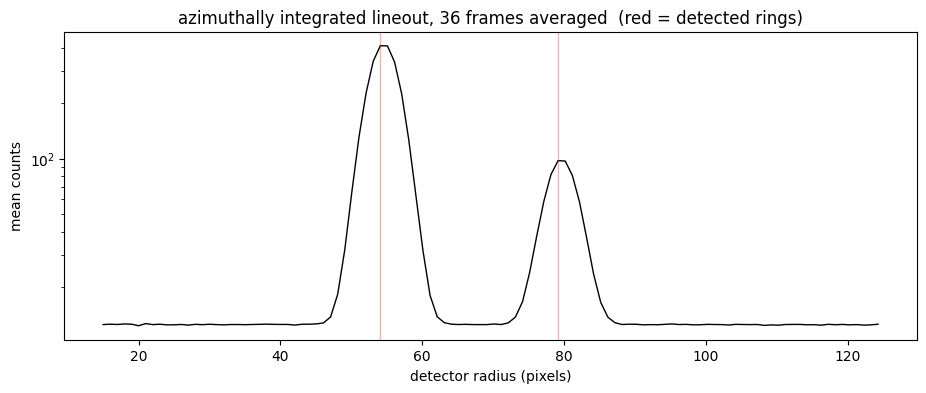

In [6]:
from midas_dt import find_rings
from midas_dt.reduce import FrameReducer

r_lo, r_hi = 15.0, float(rr.max() * 0.92)
survey = Channel(r_lo, r_hi, r_bin=1.0, eta_bin=360.0, label="survey")
reducer = FrameReducer(geo, survey, dark=dark)

acc, n = None, 0
for t in np.linspace(0, scan.n_translations - 1, min(6, scan.n_translations)).astype(int):
    for f in np.linspace(0, scan.n_frames - 1, min(6, scan.n_frames)).astype(int):
        p = reducer.reduce_frame(scan.frame(int(t), int(f))).lineout
        acc = p if acc is None else acc + p
        n += 1
lineout = acc / n
# channel.radii() rather than building the axis by hand: the two must have the
# same length or every d-spacing is assigned to the wrong bin.
radii = survey.radii()
assert radii.size == lineout.size, (radii.size, lineout.size)

rings = []
if HAVE_SCIPY:
    rings = find_rings(radii, lineout, geometry=geo, min_snr=3.0,
                       min_separation_px=3.0)
    print(f"{len(rings)} rings above 3 sigma (averaged over {n} frames)\n")
    print(f"{'R (px)':>8} {'d (A)':>9} {'SNR':>7} {'width':>7}")
    for ring in rings:
        d = f"{ring.d_spacing_a:9.4f}" if ring.d_spacing_a else "        -"
        print(f"{ring.radius_px:8.2f} {d} {ring.snr:7.1f} {ring.width_px:7.2f}")
else:
    print("scipy not installed -- cannot find rings automatically. "
          "Set CHANNEL_R_MIN/MAX by eye from the plot below.")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(radii, lineout, lw=1.0, color="k")
for ring in rings:
    ax.axvline(ring.radius_px, color="tab:red", alpha=0.35, lw=1.0)
ax.set(xlabel="detector radius (pixels)", ylabel="mean counts",
       title=f"azimuthally integrated lineout, {n} frames averaged"
             f"  (red = detected rings)")
ax.set_yscale("log")
fig.savefig(FIG / "lineout.png", dpi=130, bbox_inches="tight")
plt.show()

In [7]:
# Choose the channel: your setting if you gave one, else the strongest ring.
if CHANNEL_R_MIN is not None and CHANNEL_R_MAX is not None:
    r_min, r_max = float(CHANNEL_R_MIN), float(CHANNEL_R_MAX)
    why = "from your configuration"
elif rings:
    best = max(rings, key=lambda x: x.snr)
    half = max(4.0 * best.width_px, 5.0)
    r_min, r_max = best.radius_px - half, best.radius_px + half
    why = f"auto: strongest ring at {best.radius_px:.1f} px (SNR {best.snr:.0f})"
else:
    raise ValueError("No rings found and CHANNEL_R_MIN/MAX not set. "
                     "Pick a window by eye from the lineout above.")

channel = Channel(r_min, r_max, eta_min=-180.0, eta_max=180.0,
                  r_bin=CHANNEL_R_BIN, eta_bin=360.0,
                  label=f"R{r_min:.0f}-{r_max:.0f}")
print(f"channel: {channel.describe()}\n  {why}")
print(f"\nThis produces {channel.n_r * channel.n_eta} sinograms, i.e. that many "
      f"reconstructions in the exact branch.")
print("eta_bin=360 integrates the whole ring into one bin. Split it (e.g. 45)")
print("only if you expect orientation dependence -- it multiplies the cost.")

channel: R33-75: r 32.8726-75.3083 px / 1, eta -180-180 deg / 360 -> 43 x 1 = 43 sinograms
  auto: strongest ring at 54.1 px (SNR 3712)

This produces 43 sinograms, i.e. that many reconstructions in the exact branch.
eta_bin=360 integrates the whole ring into one bin. Split it (e.g. 45)
only if you expect orientation dependence -- it multiplies the cost.


## 6 · Reduce the frames to sinograms

Every frame is integrated over the channel, giving one radial profile per
(translation, rotation). Stacked, those are the sinograms the reconstruction
inverts. Poisson uncertainties are propagated here and carried through.

**The snake check.** Many scans alternate translation direction to save time
("snake" or bidirectional). If that is not undone, every second row of the
sinogram is reversed and the reconstruction is scrambled. `detect_snake` decides
**from the data** rather than trusting a flag, because a flag set by hand is
wrong in one direction or the other and nothing downstream notices.

one translation took 0.17 s -> estimate 0.0 min for all 16



  translation 3/16


  translation 6/16


  translation 9/16
  translation 12/16


  translation 15/16
reduced in 1.4 s

snake scan: not detected (gain 0.55)
  gain > 1 means un-snaking made the sinogram more consistent.
  If this disagrees with what you believe the scan did, stop and find out which is right before going on.

sinograms: R33-75: 43 sinograms of 24 x 16 (eta x r = 1 x 43), snake_corrected=False


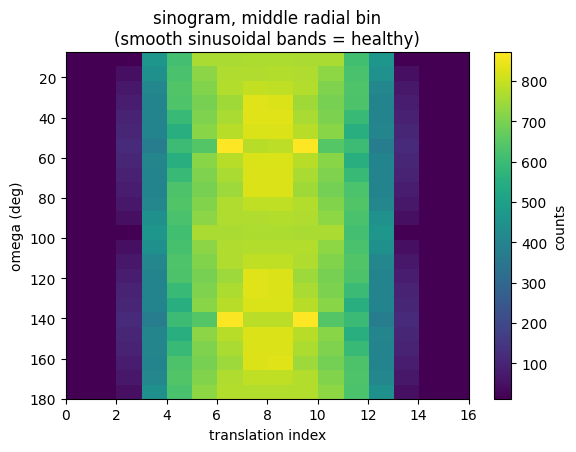

In [8]:
reducer = FrameReducer(geo, channel, dark=dark)

t0 = time.time()
one = reducer.reduce_translation(scan, 0)
per_translation = time.time() - t0
print(f"one translation took {per_translation:.2f} s -> estimate "
      f"{per_translation * scan.n_translations / 60:.1f} min for all "
      f"{scan.n_translations}\n")

inten, var = [one[0]], [one[1]]
for t in range(1, scan.n_translations):
    i, v = reducer.reduce_translation(scan, t)
    inten.append(i); var.append(v)
    if scan.n_translations > 10 and t % max(1, scan.n_translations // 5) == 0:
        print(f"  translation {t}/{scan.n_translations}")
inten, var = np.stack(inten), np.stack(var)
print(f"reduced in {time.time() - t0:.1f} s")

from midas_dt import assemble, detect_snake
profiles = inten.reshape(inten.shape[0], inten.shape[1], -1).sum(axis=2)
snake, gain = detect_snake(profiles)
print(f"\nsnake scan: {'DETECTED' if snake else 'not detected'} (gain {gain:.2f})")
print("  gain > 1 means un-snaking made the sinogram more consistent.")
print("  If this disagrees with what you believe the scan did, stop and find out"
      " which is right before going on.")

stack = assemble(inten, var, scan.omega_deg, channel, snake=snake)
print(f"\nsinograms: {stack.describe()}")

s = stack.intensity[stack.intensity.shape[0] // 2]
fig, ax = plt.subplots(figsize=(6.5, 4.5))
im = ax.imshow(s, aspect="auto", cmap="viridis",
               extent=[0, s.shape[1], scan.omega_deg[-1], scan.omega_deg[0]])
ax.set(xlabel="translation index", ylabel="omega (deg)",
       title="sinogram, middle radial bin\n(smooth sinusoidal bands = healthy)")
fig.colorbar(im, ax=ax, label="counts")
fig.savefig(FIG / "sinogram.png", dpi=130, bbox_inches="tight")
plt.show()

## 7 · Where is the rotation axis?

If the rotation axis is not at the centre of the translation range, the
reconstruction blurs and doubles edges. This estimates the offset.

A `POORLY DETERMINED` warning is not a failure — it means the centre-of-mass
method had little to work with, which is exactly what happens when the sample is
already well centred (the answer is then ~0 and correct) or when the channel
carries little signal. If your reconstruction in §8 looks doubled, come back and
try a few values of `shift` by hand.

In [9]:
from midas_dt import find_centre
centre = find_centre(stack, method="com", cross_check=False)
print(f"rotation axis: {centre.describe()}")
SHIFT = centre.shift
print(f"\nusing shift = {SHIFT:.3f} px")

centre-of-mass fit is poor (rms 0.001 vs spread 0.001): the sample may be truncated, or the chosen bins may carry no signal


rotation axis: axis shift -0.000 px (com)  [POORLY DETERMINED]

using shift = -0.000 px


## 8 · Reconstruct, then fit every voxel

Two routes ship, and they are not equivalent:

| | what it does | cost | exact? |
|---|---|---|---|
| **`run_recon_then_fit`** | reconstruct every bin, then fit the pattern at each voxel | `n_r × n_eta` reconstructions | **yes** |
| `run_fit_then_recon` | fit each projection, then reconstruct the fitted parameters | 12 reconstructions | only for 3 of the 12 outputs |

Start with `run_recon_then_fit`. It is the honest one.

The reason the other is limited: back-projection is linear, peak fitting is not.
Only quantities that **add along a ray** can be back-projected —
`TotalIntensity`, `TotalIntensityBackgroundCorr`, `FitIntegratedIntensity`. A
peak *position* does not add, so back-projecting fitted positions gives a
physically meaningless number that looks perfectly reasonable. If you use the
fast branch, `compare()` measures the disagreement on your own data.

In [10]:
from midas_dt import run_recon_then_fit

if not backend_c.available():
    raise RuntimeError("The reconstruction engine is not built -- see §0.\n"
                       + backend_c.why_unavailable())

t0 = time.time()
result = run_recon_then_fit(stack, shift=SHIFT, n_cpus=N_CPUS)
print(f"{result.describe()}\nreconstructed and fitted in {time.time() - t0:.1f} s")
print(f"\nthe 12 fitted quantities available per voxel:")
for i, name in enumerate(midas_dt.FIT_OUTPUT_NAMES):
    add = "  (additive)" if midas_dt.is_additive(name) else ""
    print(f"  {i:2d}  {name}{add}")

recon-then-fit: 12 maps of 32x32 for R33-75
reconstructed and fitted in 0.7 s

the 12 fitted quantities available per voxel:
   0  RMEAN
   1  MixFactor
   2  SigmaG
   3  SigmaL
   4  MaxInt
   5  MaxIntensityObs
   6  BGFit
   7  BGSimple
   8  MeanError
   9  FitIntegratedIntensity  (additive)
  10  TotalIntensity  (additive)
  11  TotalIntensityBackgroundCorr  (additive)


## 9 · The maps

`TotalIntensity` is how much of this ring each voxel produced — a phase-density
map for the phase that ring belongs to. `RMEAN` is the fitted ring radius per
voxel, which converts to d-spacing and hence lattice parameter and strain.

Voxels outside the sample are left as `NaN` (shown blank) rather than filled
with a fit to noise.

In demo mode the true phase map is plotted alongside, so you can see the
workflow recovered the object.

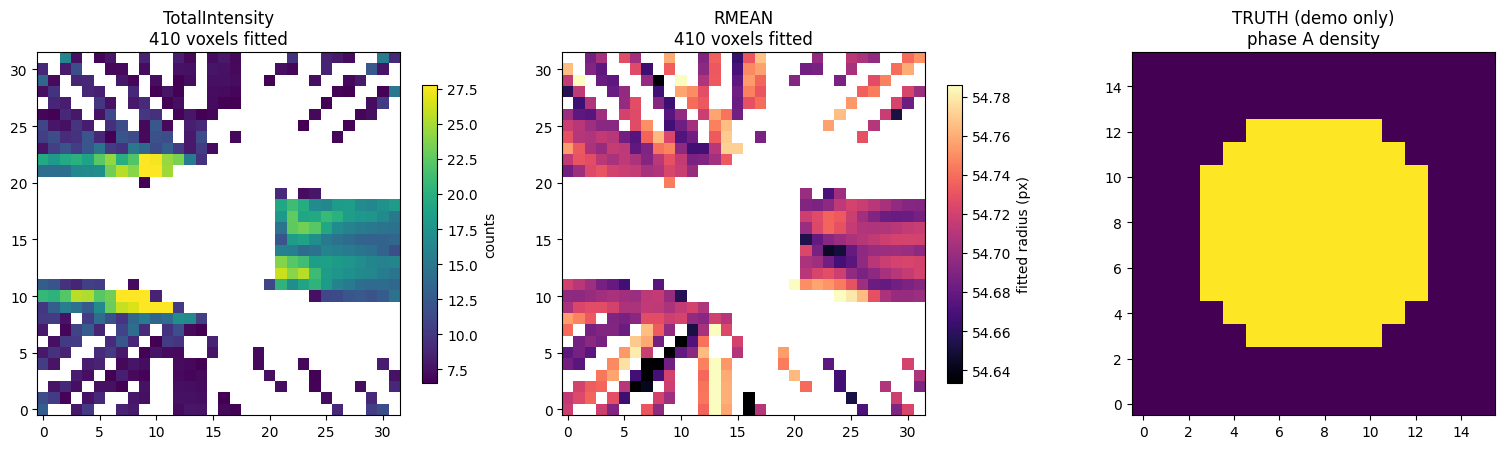

RMEAN over fitted voxels: mean 54.711 px, std 0.0327 px, range 54.61-54.82
  channel window was 32.9-75.3 px.
  If RMEAN sits at the window centre with near-zero spread, the
  window probably contains no peak -- go back to §5.


In [11]:
maps = result.maps
show = [("TotalIntensity", "counts", "viridis"),
        ("RMEAN", "fitted radius (px)", "magma")]

ncol = len(show) + (1 if demo is not None else 0)
fig, axes = plt.subplots(1, ncol, figsize=(5.2 * ncol, 4.6))
axes = np.atleast_1d(axes)

for ax, (name, label, cmap) in zip(axes, show):
    m = maps[name]
    finite = m[np.isfinite(m)]
    vmin, vmax = (np.percentile(finite, [2, 98]) if finite.size else (0, 1))
    im = ax.imshow(m, cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
    ax.set_title(f"{name}\n{np.isfinite(m).sum()} voxels fitted")
    fig.colorbar(im, ax=ax, shrink=0.82, label=label)

if demo is not None:
    ax = axes[-1]
    ax.imshow(demo.truth["A"], cmap="viridis", origin="lower")
    ax.set_title("TRUTH (demo only)\nphase A density")

fig.tight_layout()
fig.savefig(FIG / "maps.png", dpi=130, bbox_inches="tight")
plt.show()

m = maps["RMEAN"][np.isfinite(maps["RMEAN"])]
if m.size:
    print(f"RMEAN over fitted voxels: mean {m.mean():.3f} px, "
          f"std {m.std():.4f} px, range {m.min():.2f}-{m.max():.2f}")
    print(f"  channel window was {channel.r_min:.1f}-{channel.r_max:.1f} px.")
    print("  If RMEAN sits at the window centre with near-zero spread, the")
    print("  window probably contains no peak -- go back to §5.")

## 10 · Read this before you use the numbers

These limits are attached to the result and written next to the maps, so a map
cannot be separated from its caveats. They are properties of the technique, not
bugs.

In [12]:
print("KNOWN LIMITS")
for w in stack.limits.warnings():
    print(f"  - {w}")

print("""
In short:
  * self-absorption is NOT corrected by default, so phase fractions are
    biased toward the sample surface and are qualitative. midas-dt can
    correct it (see below) but needs an attenuation coefficient from you.
  * phase fractions are RELATIVE -- uncorrected for structure factor,
    multiplicity and Lorentz-polarisation. Comparable between voxels of one
    map; not between phases.
  * a strain map from ONE ring is one projection of the strain tensor along
    that scattering vector, not the tensor. Several non-parallel rings are
    needed for the tensor.
  * the eta-integrated pattern is a powder pattern only if the voxel is
    randomly oriented. Texture breaks that.
""")

KNOWN LIMITS
  - Self-absorption not corrected: phase fractions are biased towards the sample surface and are qualitative only.
  - Texture not corrected: the eta-integrated pattern is a powder pattern only if the voxel is randomly oriented.

In short:
  * self-absorption is NOT corrected by default, so phase fractions are
    biased toward the sample surface and are qualitative. midas-dt can
    correct it (see below) but needs an attenuation coefficient from you.
  * phase fractions are RELATIVE -- uncorrected for structure factor,
    multiplicity and Lorentz-polarisation. Comparable between voxels of one
    map; not between phases.
  * a strain map from ONE ring is one projection of the strain tensor along
    that scattering vector, not the tensor. Several non-parallel rings are
    needed for the tensor.
  * the eta-integrated pattern is a powder pattern only if the voxel is
    randomly oriented. Texture breaks that.



## 11 · Save

Writes the maps, the figures and a `provenance.json` recording the geometry,
conventions and limits used. The provenance is the point: in six months it is
the only way to know whether `NEGATE_OMEGA` was set correctly for this run.

In [13]:
from midas_dt import write_result
written = write_result(result, OUT_DIR / "maps")
print(f"maps      -> {OUT_DIR / 'maps'}")
print(f"figures   -> {FIG}")
for p in (sorted(Path(OUT_DIR / 'maps').glob('*'))[:8] if (OUT_DIR / 'maps').exists() else []):
    print(f"    {p.name}")

maps      -> dt_output/maps
figures   -> dt_output/figures
    BGFit.npy
    BGSimple.npy
    FitIntegratedIntensity.npy
    MaxInt.npy
    MaxIntensityObs.npy
    MeanError.npy
    MixFactor.npy
    RMEAN.npy


## Where to go next

**Both branches, and the disagreement between them**

```python
from midas_dt import run_fit_then_recon, compare, format_comparison
fast = run_fit_then_recon(stack, shift=SHIFT)
print(format_comparison(compare(fast, result), fast, result))
```

**Self-absorption** (needs the `[direct]` extra). Exact inside the forward
model, approximate for the branches above:

```python
from midas_dt import attenuation_factors, uniform_mu, run_direct
mu = uniform_mu(sample_mask, mu_per_pixel=0.05)
A  = attenuation_factors(mu, scan.omega_deg, two_theta_deg=1.2)
exact = run_direct(stack, attenuation=A)              # exact
```

**Streaky reconstruction from few rotations?** `sirt()` and `tv_reconstruct()`
suppress the artefacts filtered back projection produces below Nyquist. Read
the caveats in the README first — `tv_weight` is not a free parameter.

**More than one ring:** build a list of `Channel`s and loop §6–9. Two channels
from different phases give a phase-fraction map via `phase_fraction_map`.

**Which phase is which ring?** `index_rings` matches your ring list against
candidate unit cells. Include a phase you know is absent as a control.

**Same workflow from the shell:**

```bash
midas-dt --params ps_dt.txt --raw-dir /data --stem sample \
         --start 161 --end 215 --dark dark.raw \
         --r-min 105 --r-max 125 --out ./maps
```

**Reference:** `packages/midas_dt/README.md` for the conventions table and the
full limits ledger; `scripts/` for the diagnostic scripts used on real data.